## Amazon Rekognition S3 - Kunskapskontroll 1
### Cyritha Ljungberg

Jag börjar med att förbereda ett dataset med 50 bilder, där jag väljer att ha 5 klasser med 10 bilder vardera.

In [14]:
# Importera bibliotek

import os
from collections import Counter
import boto3
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

# Installera dessa om de inte redan finns

Antal bilder: 50


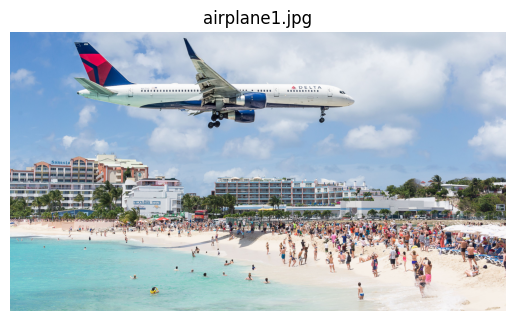

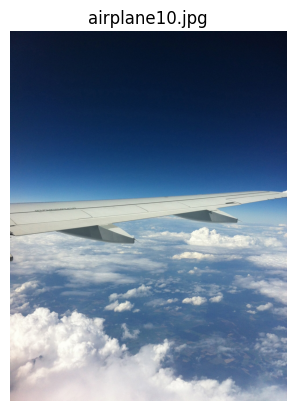

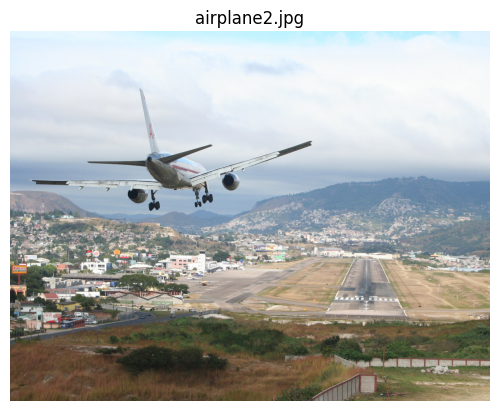

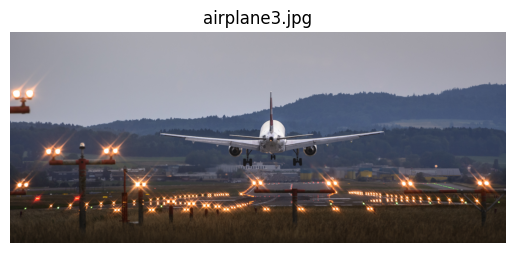

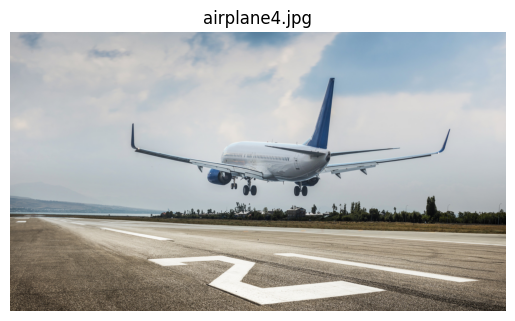

In [15]:
# Exempel på bilder

IMAGE_FOLDER = "Rekognition_Images"

files = [f for f in os.listdir(IMAGE_FOLDER) if f.endswith((".jpg", ".jpeg", ".png"))]

print(f"Antal bilder: {len(files)}")

for file in files[:5]:   # visar 5 bilder
    img = Image.open(f"{IMAGE_FOLDER}/{file}")
    
    plt.imshow(img)
    plt.title(file)
    plt.axis("off")
    plt.show()

In [ ]:
# Koppla till Amazon Rekognition

client = boto3.client(
    "rekognition",
    region_name= <Add region>
    aws_access_key_id= <Add key>,
    aws_secret_access_key= <Add key>
)

print("Koppling fungerar!")

Koppling fungerar!


In [12]:
# Testa Rekognition på en bild

test_file = files[0]

with open(f"{IMAGE_FOLDER}/{test_file}", "rb") as image:
    response = client.detect_labels(
        Image={"Bytes": image.read()},
        MaxLabels=5,
        MinConfidence=70
    )

print("Bild:", test_file)

for label in response["Labels"]:
    print(label["Name"], "-", round(label["Confidence"], 2))

Bild: airplane1.jpg
Airliner - 99.99
Airplane - 99.99
Flight - 99.68
Person - 98.28
Landing - 95.82


In [18]:
bad_files = []
good_files = []

for file_name in files:
    try:
        with open(f"{IMAGE_FOLDER}/{file_name}", "rb") as image:
            client.detect_labels(
                Image={"Bytes": image.read()},
                MaxLabels=1,
                MinConfidence=70
            )
        good_files.append(file_name)

    except Exception:
        bad_files.append(file_name)

print("Fungerande bilder:", len(good_files))
print("Felaktiga bilder:", len(bad_files))

print("\nFiler som inte fungerar:")
for f in bad_files:
    print(f)

Fungerande bilder: 48
Felaktiga bilder: 2

Filer som inte fungerar:
airplane7.jpg
tree8.jpg


In [19]:
bad_files = []
good_files = []

for file_name in files:
    try:
        with open(f"{IMAGE_FOLDER}/{file_name}", "rb") as image:
            client.detect_labels(
                Image={"Bytes": image.read()},
                MaxLabels=1,
                MinConfidence=70
            )
        good_files.append(file_name)

    except Exception:
        bad_files.append(file_name)

print("Fungerande bilder:", len(good_files))
print("Felaktiga bilder:", len(bad_files))

print("\nFiler som inte fungerar:")
for f in bad_files:
    print(f)

Fungerande bilder: 50
Felaktiga bilder: 0

Filer som inte fungerar:


In [ ]:
# Loopar igenom bilderna, skickar till AWS Rekognition, tar top 1-label, räknar hur ofta varje label förekommer och sparar resultatet för analys i tabellform

label_counter = Counter()
image_results = []

for file_name in files:
    with open(f"{IMAGE_FOLDER}/{file_name}", "rb") as image:
        result = client.detect_labels(
            Image={"Bytes": image.read()},
            MaxLabels=5,
            MinConfidence=70
        )

    labels = result["Labels"]

    if labels:
        top_label = labels[0]["Name"]
        top_confidence = labels[0]["Confidence"]

        label_counter[top_label] += 1

        image_results.append({
            "file_name": file_name,
            "top_label": top_label,
            "confidence": top_confidence
        })

print("Klar med analys!")

Klar med analys!


In [25]:

df_results = pd.DataFrame(image_results)

top = label_counter.most_common(10)

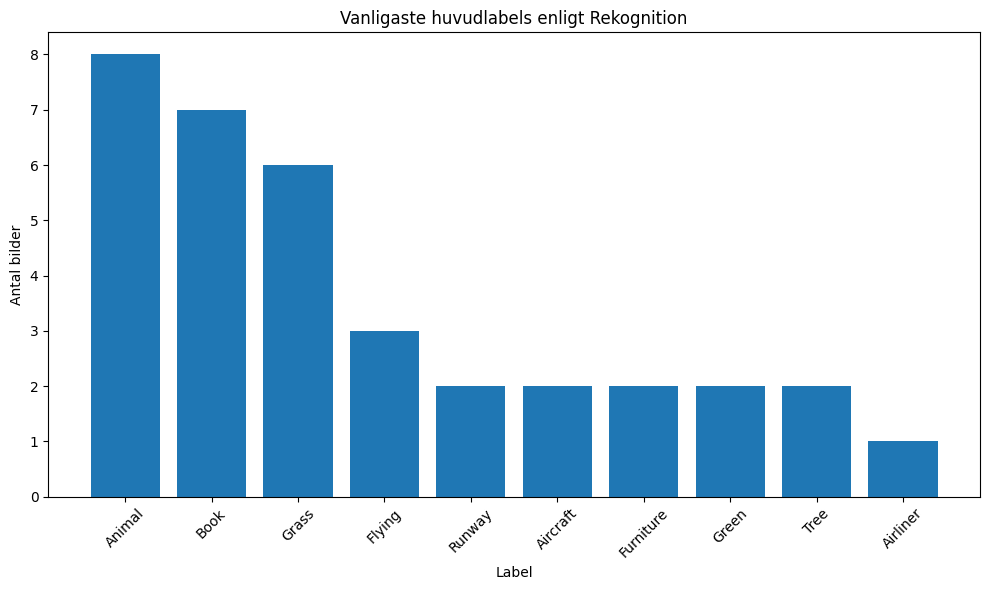

,file_name,top_label,confidence
0,airplane1.jpg,Airliner,99.991562
1,airplane10.jpg,Nature,99.999977
2,airplane2.jpg,Runway,99.925331
3,airplane3.jpg,Airport,99.744118
4,airplane4.jpg,Runway,99.960938


In [26]:
labels = [x[0] for x in top]
values = [x[1] for x in top]

plt.figure(figsize=(10, 6))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Vanligaste huvudlabels enligt Rekognition")
plt.xlabel("Label")
plt.ylabel("Antal bilder")
plt.tight_layout()
plt.show()

df_results.head()

In [27]:
top = label_counter.most_common(10)

for label, count in top:
    print(label, ":", count)

Animal : 8
Book : 7
Grass : 6
Flying : 3
Runway : 2
Aircraft : 2
Furniture : 2
Green : 2
Tree : 2
Airliner : 1


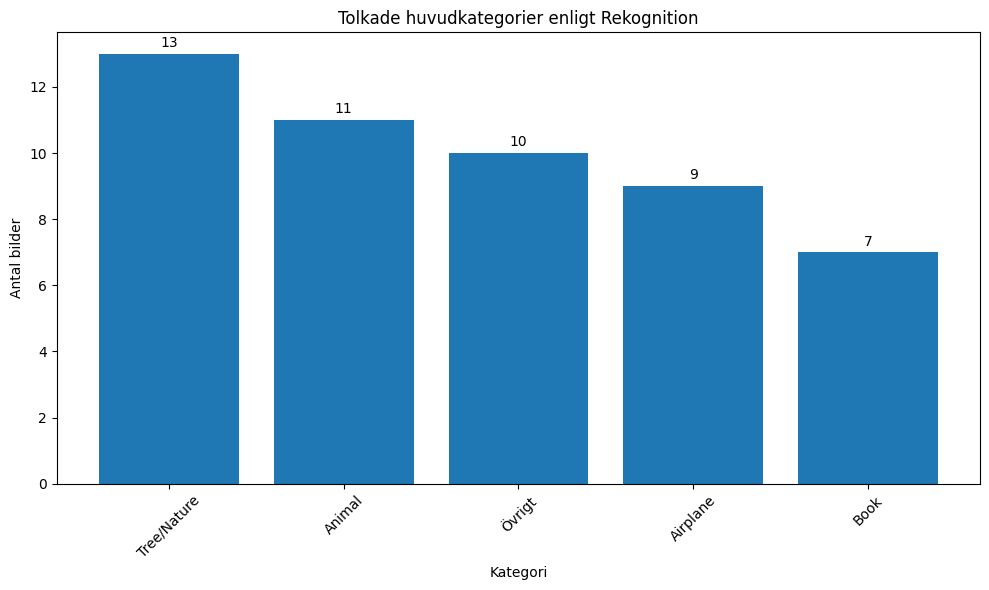

In [ ]:
# Tar labels från AI-resultatet, översätter till egna kategorier, räknar bilder per kategori och visualiserar resultatet i ett diagram
def map_to_category(label):
    airplane_labels = ["Airliner", "Aircraft", "Airplane", "Flying", "Flight", "Runway", "Airport"]
    tree_labels = ["Tree", "Grass", "Green", "Forest", "Nature", "Plant", "Outdoors", "Vegetation"]
    book_labels = ["Book", "Publication", "Text", "Library", "Notebook"]
    animal_labels = ["Animal", "Cat", "Dog", "Pet", "Mammal", "Canine", "Feline"]
    
    if label in airplane_labels:
        return "Airplane"
    elif label in tree_labels:
        return "Tree/Nature"
    elif label in book_labels:
        return "Book"
    elif label in animal_labels:
        return "Animal"
    else:
        return "Övrigt"

df_results["mapped_category"] = df_results["top_label"].apply(map_to_category)

category_counts = df_results["mapped_category"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(category_counts.index, category_counts.values)

# lägg siffror ovanför staplarna
for i, v in enumerate(category_counts.values):
    plt.text(i, v + 0.2, str(v), ha='center')

plt.xticks(rotation=45)
plt.title("Tolkade huvudkategorier enligt Rekognition")
plt.xlabel("Kategori")
plt.ylabel("Antal bilder")
plt.tight_layout()
plt.show()

Resultatet visar att Amazon Rekognition inte alltid använder samma label för liknande bilder, utan ofta flera närliggande begrepp. Exempelvis kunde flygbilder klassificeras som både “Airliner”, “Aircraft”, “Flying” och “Runway”, medan naturbilder kunde identifieras som “Tree”, “Grass” eller “Nature”.

För att göra resultatet mer överskådligt grupperades därför liknande labels till större huvudkategorier. Detta visar hur AI-tjänster kan ge flexibla men ibland mindre konsekventa tolkningar av visuellt innehåll.

In [ ]:
df_results.sort_values(by="confidence", ascending=False)

,file_name,top_label,confidence,mapped_category
11,book10.jpg,Book,100.000000,Book
8,airplane8.jpg,Flying,100.000000,Airplane
15,book5.jpg,Person,100.000000,Övrigt
41,tree10.jpg,Tree,100.000000,Tree/Nature
49,tree9.jpg,Plant,100.000000,Tree/Nature
48,tree8.jpg,Tree,100.000000,Tree/Nature
46,tree6.jpg,Grass,100.000000,Tree/Nature
47,tree7.jpg,Oak,100.000000,Övrigt
43,tree3.jpg,Grove,100.000000,Övrigt
42,tree2jpg.jpg,Green,100.000000,Tree/Nature


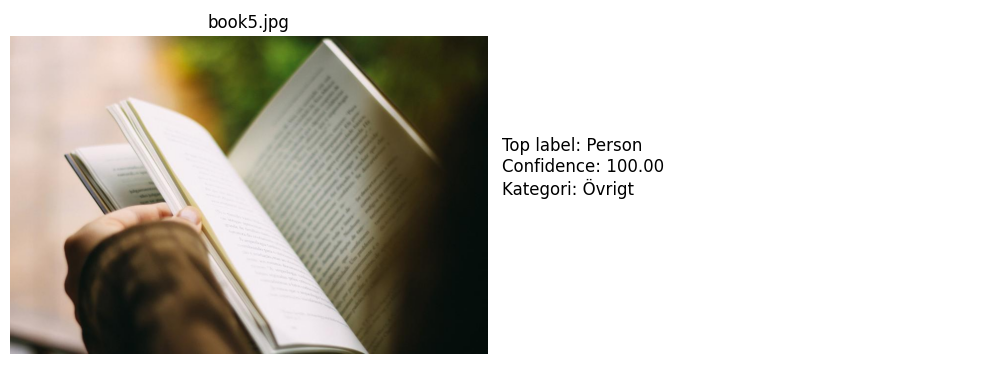

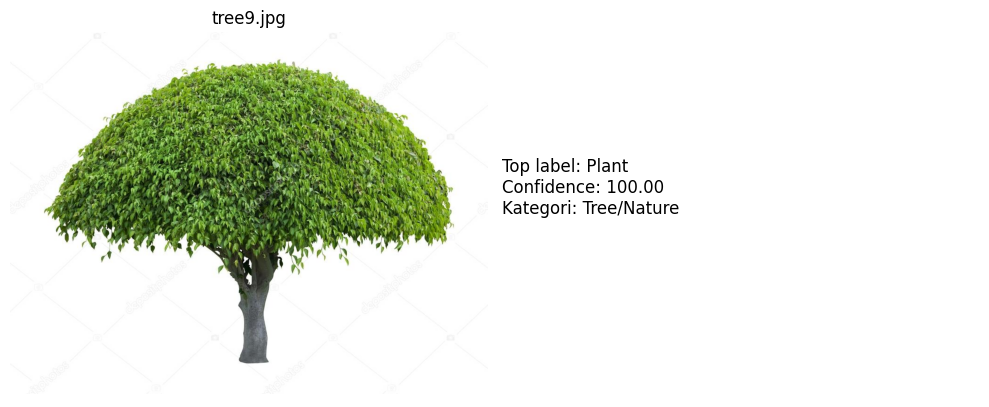

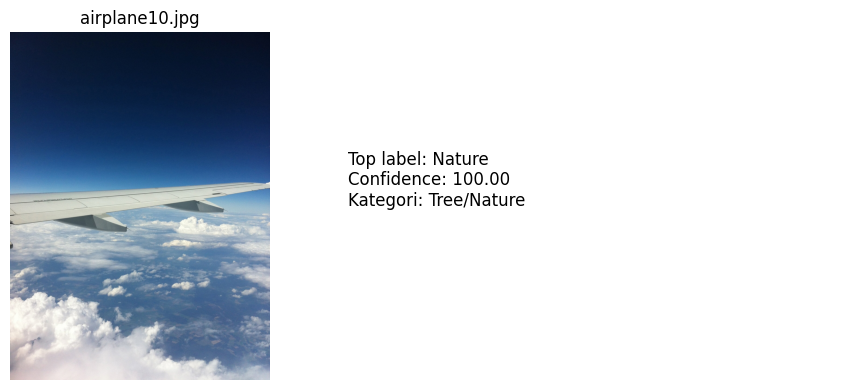

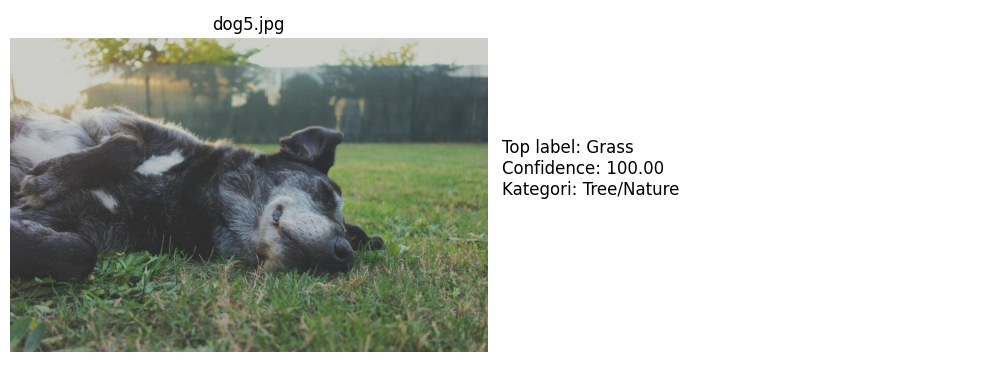

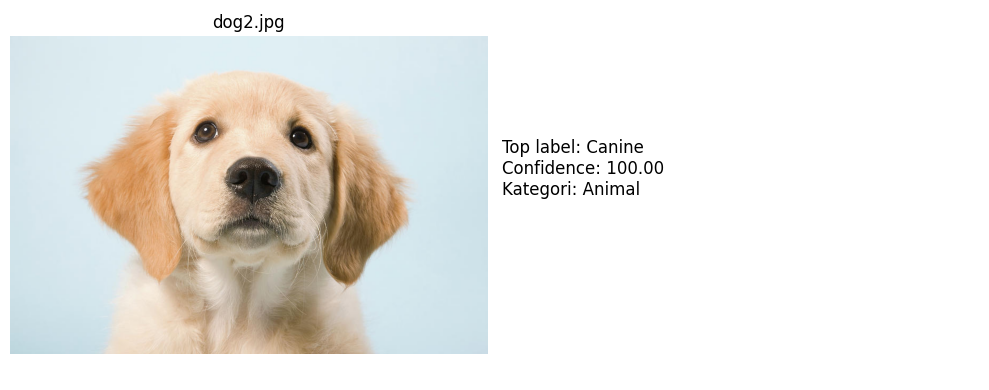

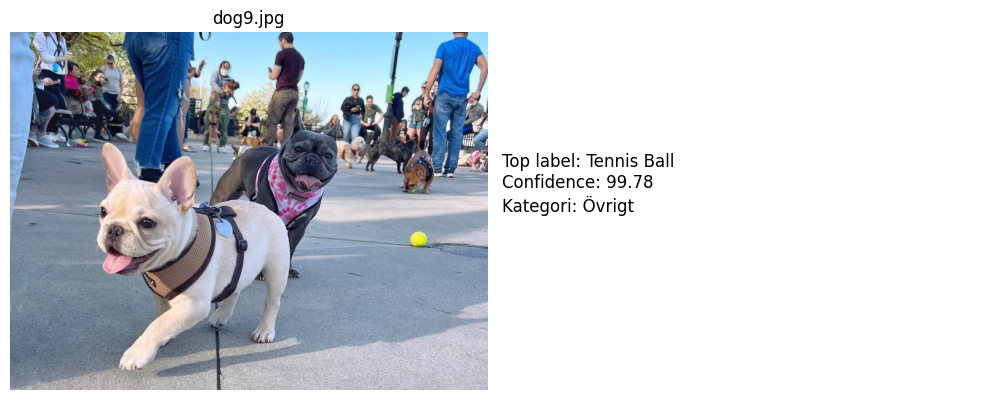

In [ ]:
# Tittar på några bilder, dess labels och confidence i %
file_names = ["book5.jpg", "tree9.jpg", "airplane10.jpg", 
              "dog5.jpg", "dog2.jpg", "dog9.jpg"]

for file_name in file_names:
    
    img = Image.open(f"{IMAGE_FOLDER}/{file_name}")
    row = df_results[df_results["file_name"] == file_name].iloc[0]
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    # visa bild
    ax[0].imshow(img)
    ax[0].set_title(file_name)
    ax[0].axis("off")
    
    # visa text
    ax[1].axis("off")
    ax[1].text(
        0, 0.5,
        f"Top label: {row['top_label']}\nConfidence: {row['confidence']:.2f}\nKategori: {row['mapped_category']}",
        fontsize=12
    )
    
    plt.tight_layout()
    plt.show()

Det blir tydligt att vissa bilder får primära labels efter omgivningen. Två hundar på asfalt med människor i bakgrunden blir t ex i första hand en tennisboll. Att ha flera lika objekt på bilden kan försvåra tolkningen. 
Vidare steg hade kunnat vara att se på top 2 eller top 3-labels för att de kanske stämmer bättre med vad vi tycker att bilden föreställer. 
Alternativt behövs lättolkade bilder t ex utan andra objekt i bakgrund för att få mer korrekta tolkningar som top 1 label. 